In [ ]:
!pip install tensorflow

In [ ]:
# checking tensorflow version:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
# unzip data:

In [ ]:
!unzip "/content/archive.zip"

Streaming output truncated to the last 5000 lines.
  inflating: train/5/00005_00053_00010.png  
  inflating: train/5/00005_00053_00011.png  
  inflating: train/5/00005_00053_00012.png  
  inflating: train/5/00005_00053_00013.png  
  inflating: train/5/00005_00053_00014.png  
  inflating: train/5/00005_00053_00015.png  
  inflating: train/5/00005_00053_00016.png  
  inflating: train/5/00005_00053_00017.png  
  inflating: train/5/00005_00053_00018.png  
  inflating: train/5/00005_00053_00019.png  
  inflating: train/5/00005_00053_00020.png  
  inflating: train/5/00005_00053_00021.png  
  inflating: train/5/00005_00053_00022.png  
  inflating: train/5/00005_00053_00023.png  
  inflating: train/5/00005_00053_00024.png  
  inflating: train/5/00005_00053_00025.png  
  inflating: train/5/00005_00053_00026.png  
  inflating: train/5/00005_00053_00027.png  
  inflating: train/5/00005_00053_00028.png  
  inflating: train/5/00005_00053_00029.png  
  inflating: train/5/00005_00054_00000.png  
  in

# Required Library:

In [ ]:
# Importing Important Library:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
target_size = (30, 30)
batch_size = 32
class_mode = 'categorical'
page_dir = '/content/Train'

In [ ]:
# Loading the data:
train_gen = ImageDataGenerator(rescale = 1./255, validation_split = 0.2)
train_gen = train_gen.flow_from_directory(page_dir,
                                  target_size = target_size,
                                  batch_size = batch_size,
                                  class_mode = class_mode,
                                  shuffle = True)

Found 39209 images belonging to 43 classes.


In [ ]:
test_gen = tf.keras.utils.image_dataset_from_directory(
    '/content/Test',
    labels=None,      # Tells Keras there are no subfolder-labels
    image_size=(64, 64),
    batch_size=32,
    shuffle = False
)

In [ ]:
meta_gen = tf.keras.utils.image_dataset_from_directory(
    '/content/Meta',
    labels=None,      # Tells Keras there are no subfolder-labels
    image_size=(64, 64),
    batch_size=32,
    shuffle = False
)

Found 43 files.


# Reading csv files & Viewing the dataframe:

In [ ]:
# Read the csv files : TRAIN, TEST, META
train_csv = pd.read_csv('/content/Train.csv')
test_csv = pd.read_csv('/content/Test.csv')
meta_csv = pd.read_csv('/content/Meta.csv')

In [ ]:
train_csv.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [ ]:
train_csv['Path'][0][9:]

'00020_00000_00000.png'

In [ ]:
test_csv.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


In [ ]:
meta_csv.head()

,Path,ClassId,ShapeId,ColorId,SignId
0,Meta/27.png,27,0,0,1.32
1,Meta/0.png,0,1,0,3.29
2,Meta/1.png,1,1,0,3.29
3,Meta/10.png,10,1,0,3.27
4,Meta/11.png,11,0,0,1.22



# Understanding the data

# pathlib

    pathlib is a biult in python libarary, which provides object-oriented way to handle the filesystem paths

# rglob:

    it perform recursive search for all files and directories matching specified patterns.

# " * *.* *"

    this is matching any file name dot and any any extension. linke image.img

# path

    path containing all images


In [ ]:
#steps to convert image dataset to dataframe

import pandas as pd
from pathlib import Path

data = '/content/Train'

paths = [path.parts[-2:] for path in
         Path(data).rglob('*.*')]                             #writing purpose ('*.*') so that all image formats can be retrieved
train_df = pd.DataFrame(data=paths, columns=['Class','Images'])

#sort index of each row
train_df = train_df.sort_values('Class',ascending=True)                   #sort class name
train_df.reset_index(drop=True, inplace=True)
train_df.head()

,Class,Images
0,0,00000_00003_00014.png
1,0,00000_00001_00002.png
2,0,00000_00001_00025.png
3,0,00000_00000_00029.png
4,0,00000_00004_00018.png


In [ ]:
# making Dataframe test data:

path = '/content/Test'
test_image = os.listdir(path)
print(test_image)

['03824.png', '00329.png', '08646.png', '00014.png', '00452.png', '06348.png', '04262.png', '08087.png', '12124.png', '10943.png', '01842.png', '00495.png', '11243.png', '05347.png', '09684.png', '09931.png', '07995.png', '08494.png', '01949.png', '03413.png', '01657.png', '09673.png', '03146.png', '01304.png', '08190.png', '03792.png', '12216.png', '01998.png', '03574.png', '03510.png', '08339.png', '10845.png', '08450.png', '08269.png', '02463.png', '09841.png', '00658.png', '01716.png', '11793.png', '03586.png', '12404.png', '01252.png', '09609.png', '04041.png', '01875.png', '02838.png', '06795.png', '04613.png', '07943.png', '09042.png', '01108.png', '03512.png', '01440.png', '12243.png', '01516.png', '00760.png', '02161.png', '11247.png', '01161.png', '09596.png', '09793.png', '05660.png', '04875.png', '11817.png', '12293.png', '04046.png', '02480.png', '00842.png', '10451.png', '09263.png', '00503.png', '10046.png', '02576.png', '03537.png', '05121.png', '08935.png', '00576.png'

In [ ]:
test_df = pd.DataFrame(data=test_image, columns=['Images'])
test_df.head()

,Images
0,03824.png
1,00329.png
2,08646.png
3,00014.png
4,00452.png


In [ ]:
# Making the DataFrame meta data:
path = "/content/meta"
meta = os.listdir(path)
meta_df = pd.DataFrame(meta, columns=['Images'])
meta_df.head()

,Images
0,21.png
1,23.png
2,.~lock.ClassesInformation.ods#
3,24.png
4,41.png


In [ ]:
# Getting an idea about data

In [ ]:
train_df.shape

(39209, 2)

In [ ]:
test_df.shape

(12631, 1)

In [ ]:
meta_df.shape

(45, 1)

In [ ]:
# here we can see, totally 43 classes but we received 45, we need to process the data

In [ ]:
meta_df['Images'].unique()

array(['21.png', '23.png', '.~lock.ClassesInformation.ods#', '24.png',
       '41.png', '18.png', '9.png', '15.png', '32.png', '14.png',
       '19.png', '4.png', '6.png', '27.png', '25.png', '40.png', '30.png',
       '26.png', '29.png', '36.png', '0.png', '22.png', '5.png', '37.png',
       '42.png', '13.png', '3.png', '35.png', '39.png', '28.png',
       '12.png', '10.png', '33.png', '38.png', '34.png', '1.png',
       '31.png', '2.png', '17.png', '11.png', '16.png', '20.png', '8.png',
       '.~lock.ClassesInformationStrong.ods#', '7.png'], dtype=object)

In [ ]:
# we have delete ".~lock.ClassesInformation.ods#"", '.~lock.ClassesInformationStrong.ods#'

In [ ]:
index1 = meta_df[meta_df['Images'] == '.~lock.ClassesInformation.ods#'].index
index2 = meta_df[meta_df['Images'] == '.~lock.ClassesInformationStrong.ods#'].index
meta_df = meta_df.drop(index1)
meta_df = meta_df.drop(index2)

In [ ]:
meta_df.shape # now we got exact 43 target classes

(43, 1)

In [ ]:
# checking null values in the data:

In [ ]:
train_df.isnull().sum().any()

np.False_

In [ ]:
test_df.isnull().sum().any()

np.False_

In [ ]:
meta_df.isnull().sum().any()

np.False_

In [ ]:
"np.False means here we dont have any null value in the data"

'np.False means here we dont have any null value in the data'

In [ ]:
# Getting an idea about duplicates data:
train_df.duplicated().sum()

np.int64(0)

In [ ]:
test_df.duplicated().sum()

np.int64(0)

In [ ]:
meta_df.duplicated().sum()

np.int64(0)

In [ ]:
'here we do have any duplicated data'

'here we do have any duplicated data'

# Indentifying the class imabalance

In [ ]:
x  = train_df['Class'].value_counts()
x

,count
Class,
2,2250
1,2220
13,2160
12,2100
38,2070
10,2010
4,1980
5,1860
25,1500


# plotting the Barplot for class imabalance:

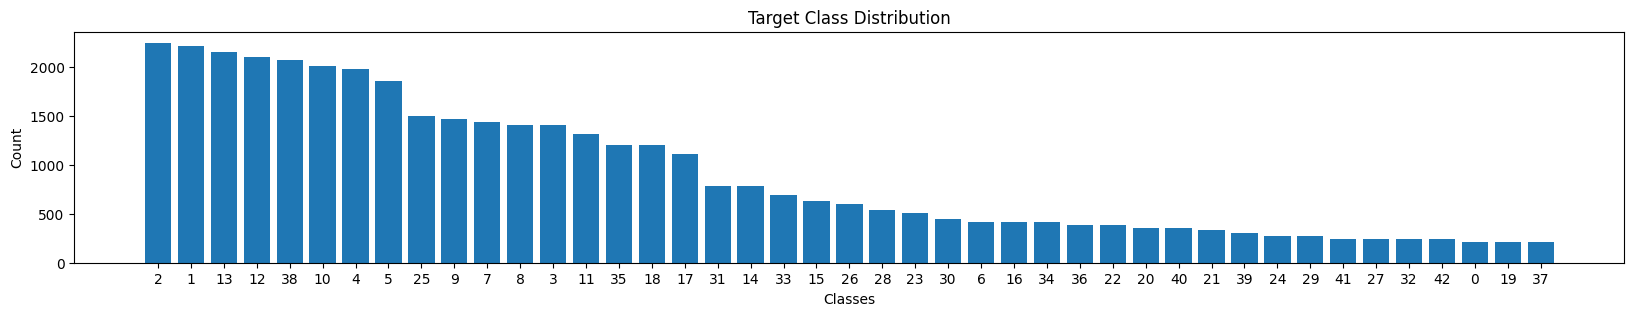

In [ ]:
# plotting the target class distribution:

plt.figure(figsize = (20, 3))
plt.bar(x.index, x.values)
plt.title('Target Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.show()

In [ ]:
# the above graph says how evenly data distributed across diff classes
# the data distribution arranged decending order

"""Here we clarly identify significant imbalance in the dataset
2 to upto 17 most frequency count arround 2000 instances
class 31 to up to 37 least frequency count below 500 instances"""




# plotting image sizes for diff classes:

In [ ]:
train_csv.sample(5)

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
25790,96,83,9,8,88,75,18,Train/18/00018_00007_00020.png
13093,33,34,5,5,28,28,8,Train/8/00008_00031_00013.png
26145,57,56,6,5,52,51,18,Train/18/00018_00019_00015.png
19177,40,39,6,5,35,34,12,Train/12/00012_00027_00007.png
28099,61,56,5,6,56,51,23,Train/23/00023_00013_00019.png


In [ ]:
len(train_csv['Path'])

39209

# Scatter plot for understanding, how images are present in the data:

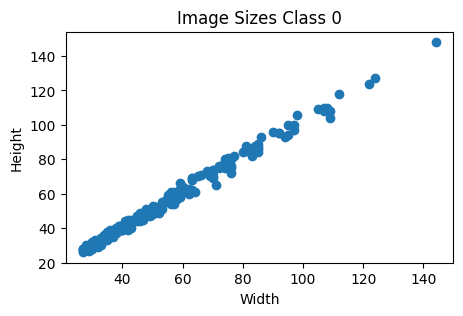

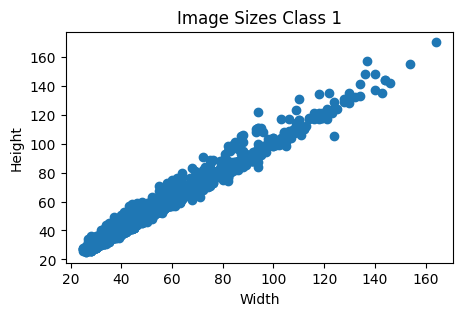

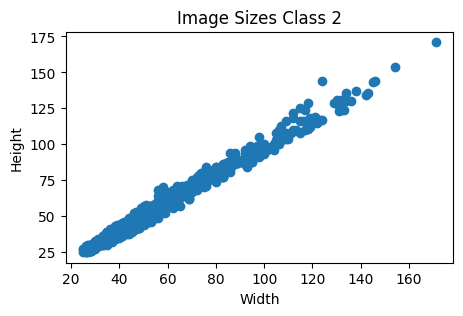

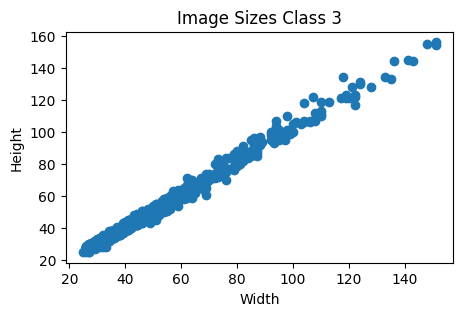

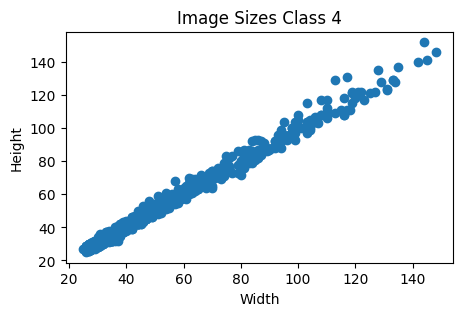

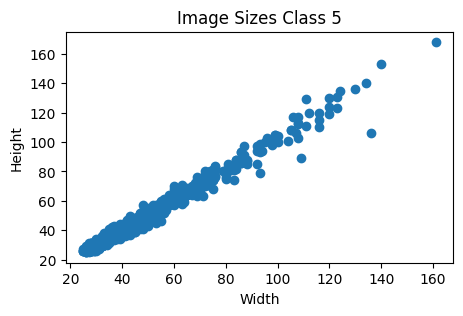

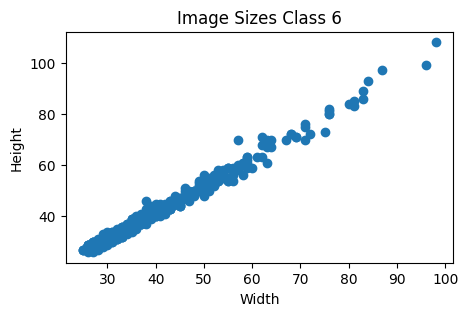

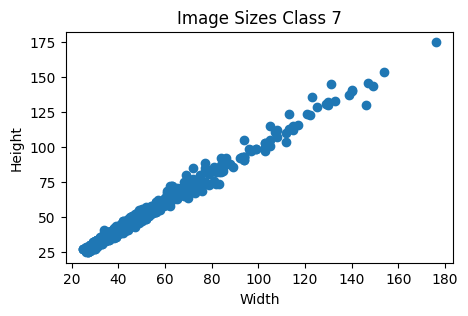

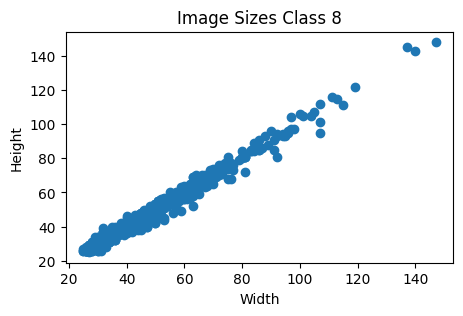

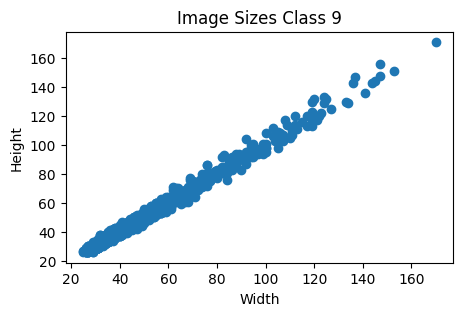

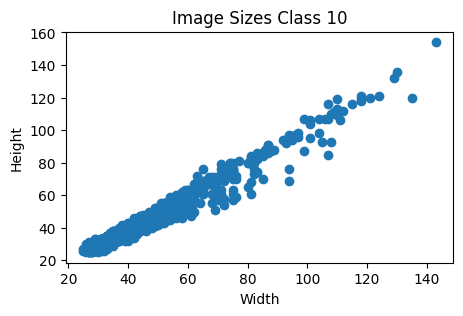

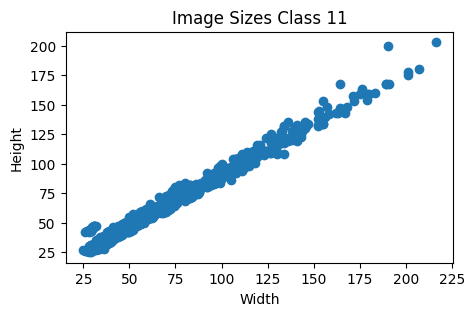

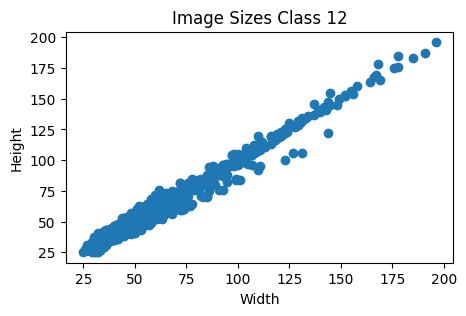

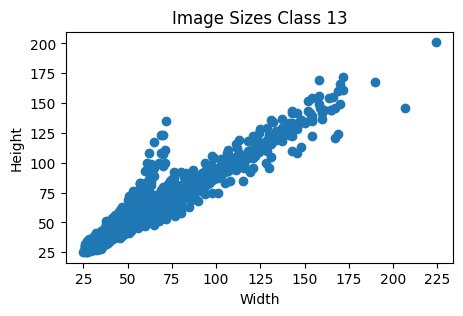

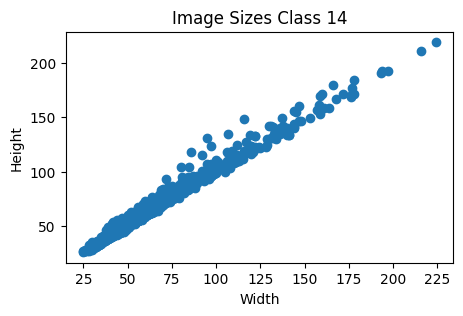

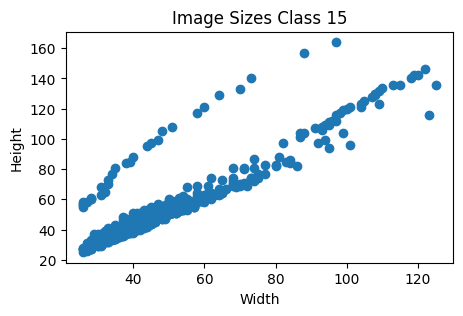

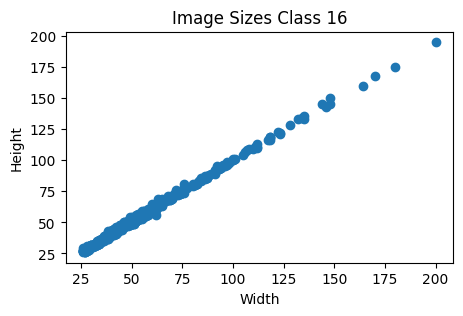

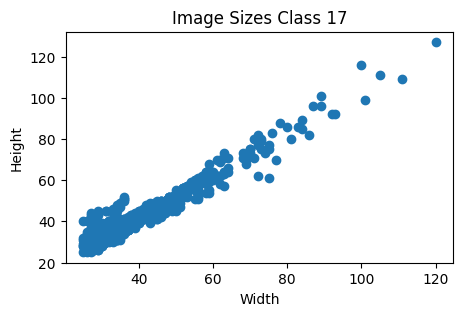

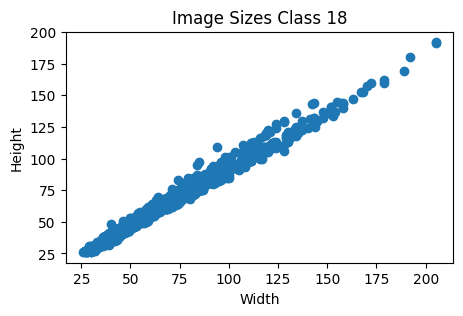

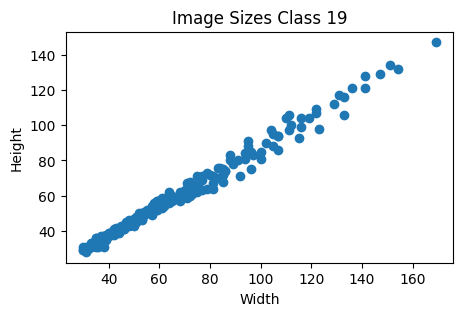

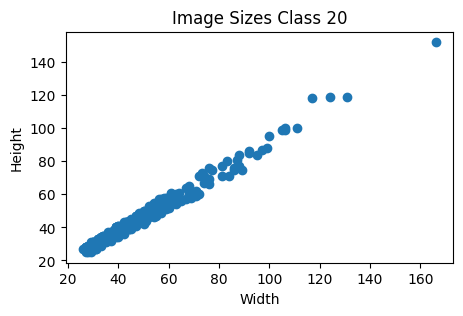

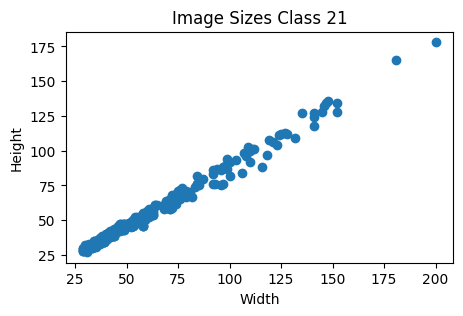

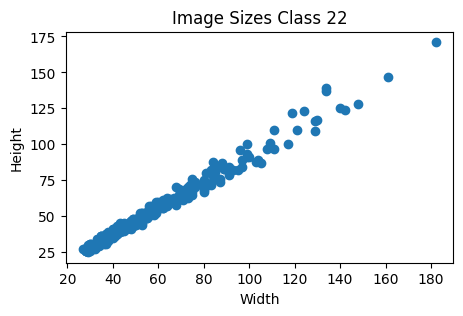

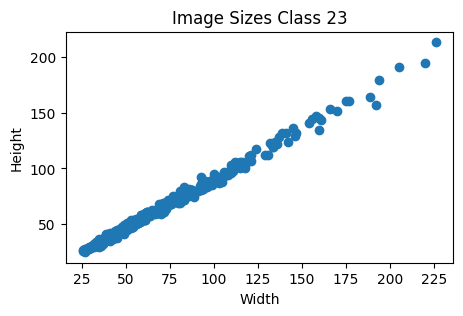

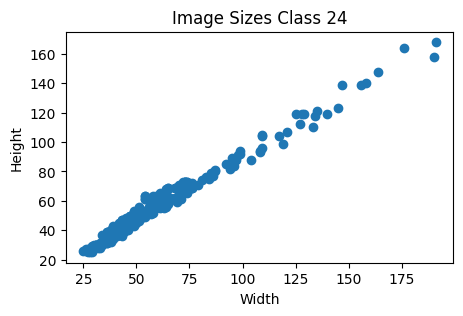

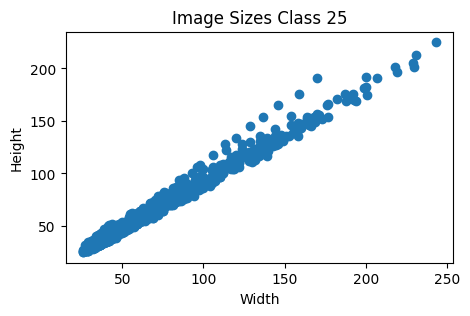

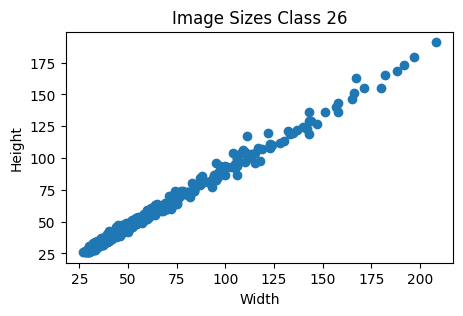

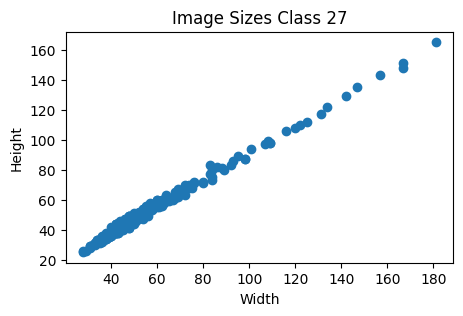

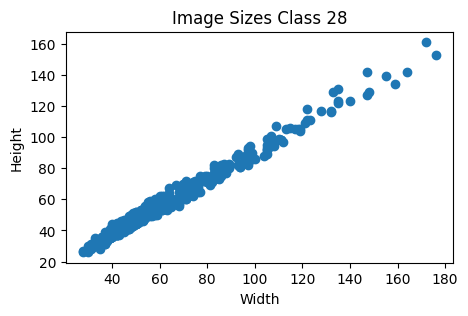

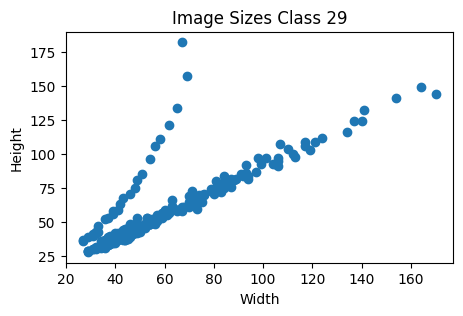

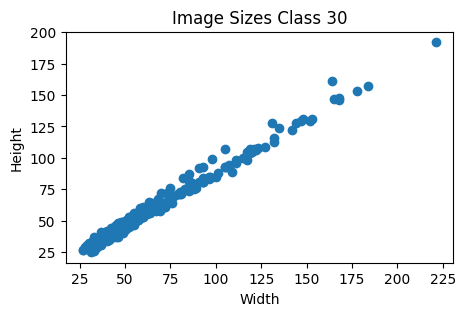

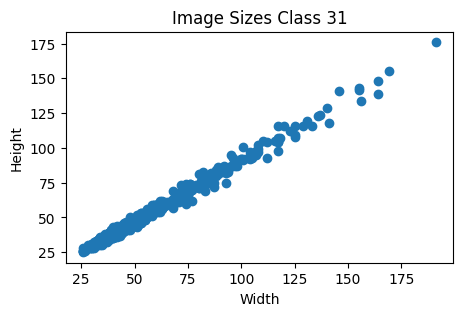

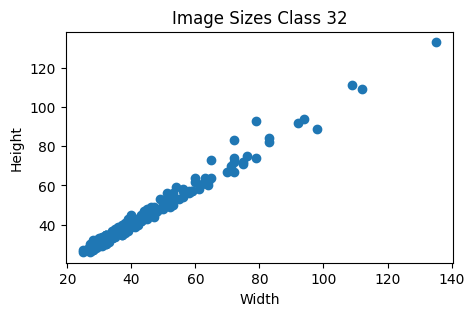

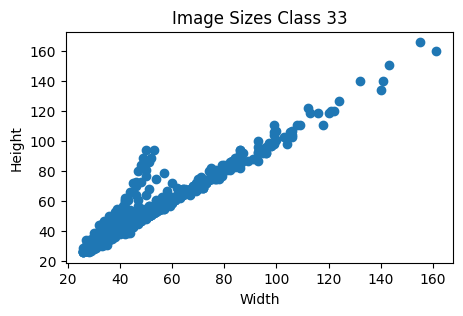

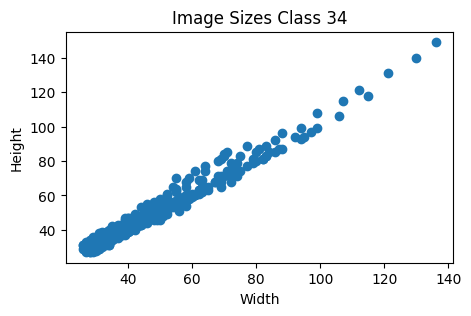

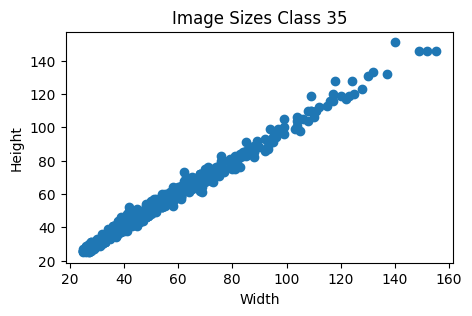

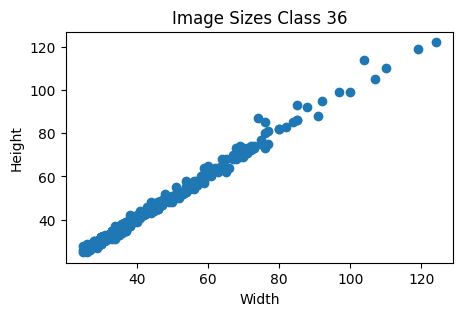

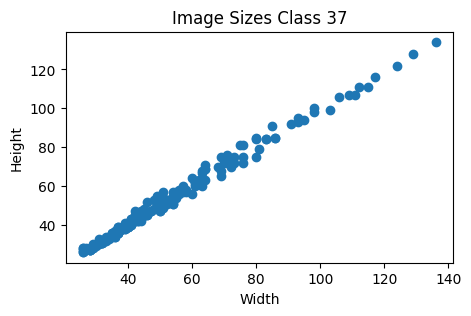

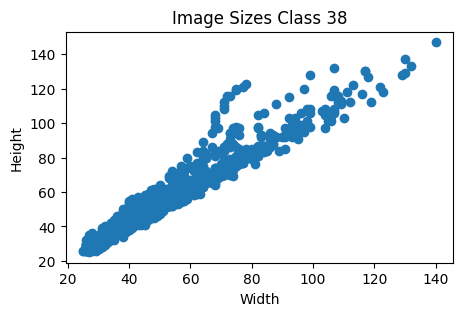

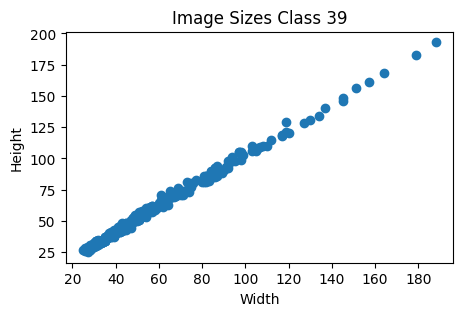

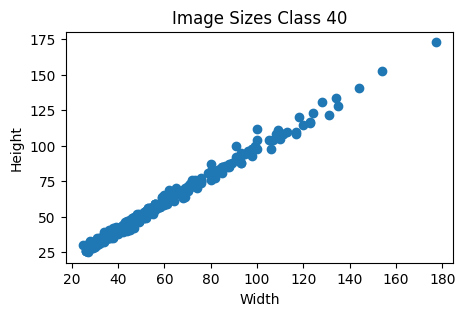

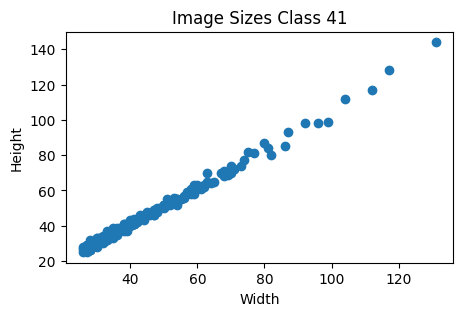

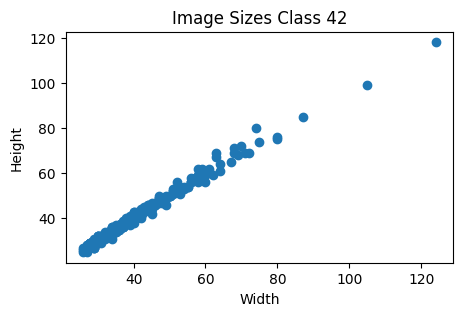

In [ ]:
for i in range(43):
  if i < 43:
    df = train_csv[train_csv['ClassId'] == i]
    plt.figure(figsize = (5, 3))
    plt.scatter(df['Width'], df['Height'])
    plt.title(f'Image Sizes Class {i}')
    plt.xlabel('Width')
    plt.ylabel('Height')
    plt.show()



In [ ]:
"""Here we can see each plot says for each target class varies images sizes,
   so that we clearly understand each image data different sizes
   our deep learning models understand same dimensions only.
   we need to convert all image data into same dimensions.
   we have to resize our data """

# viewing sample images :

In [ ]:
# Step 3 : Show sample dataset images
def show_sample_images(generator):
  x, y = next(generator)
  plt.figure(figsize = (9, 3))
  for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x[i])
    plt.title(list(generator.class_indices.keys())[np.argmax(y[i])])
    plt.axis('off')
  plt.show()


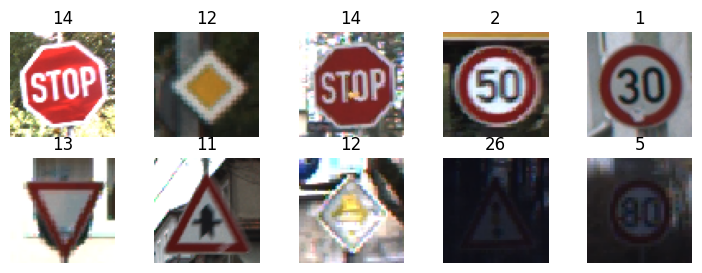

In [ ]:
# Driver Code
show_sample_images(train_gen)

In [ ]:
""" the images shows various traffic sign used for train the model
some images blur and not showing clear ex 13, some images shows speed 50, 100,60,70
that is very useful for us

label 12 Right-of-Way: Drivers on this road can proceed through intersections without stopping,
label 13 give a way driver to carefull make slow down
label 14 says full stop ,this sign to avoid accidents
laebl 2 shows a speed limit of "50" km/h.
this kinds of ideas we have to understand
some of the image very clear and some of the image not clear
"""

In [ ]:
import matplotlib.image as mpimg
path = train_csv['Path'][0]
img = mpimg.imread(path)
img.shape

(26, 27, 3)

In [ ]:
"""(26, 27, 3) shape of the image data
    26 -> is the height of the image
    27 -> is the with of the
    3  -> channel of the image, 3 indicates its a color image data rgb channels"""

In [ ]:
import matplotlib.image as mpimg
path = train_csv['Path'][5]
img = mpimg.imread(path)
img.shape

(27, 31, 3)

In [ ]:
'''we should understand over here each image diff dimensions.
   we should convert every image same dimensions'''

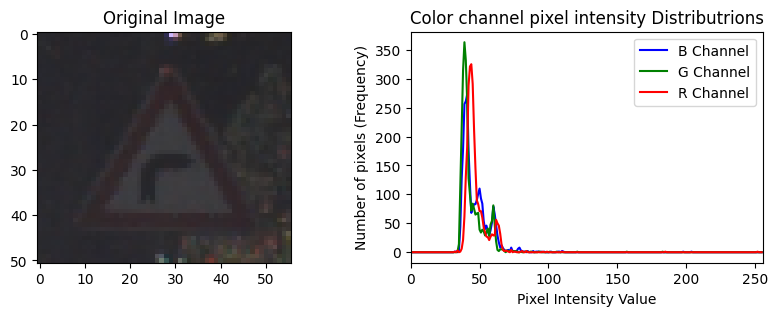

In [ ]:
import cv2
path = train_csv['Path'][20]
img = cv2.imread(path)

# Basically cv2 read BGR we have to convert required RGB channels
image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# split the image repective channels
channels = cv2.split(image)
colors = ['b', 'g', 'r']

# plot the image

plt.figure(figsize = (10, 3))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.subplot(1, 2, 2)
plt.title('Color channel pixel intensity Distributrions')
plt.xlabel("Pixel Intensity Value")
plt.ylabel("Number of pixels (Frequency)")
plt.xlim([0, 256])

for channel, color in zip(channels, colors):
  hist = cv2.calcHist([channel], [0], None, [256], [0, 256])
  plt.plot(hist, color = color, label = f"{color.upper()} Channel")
plt.legend()
plt.show()


In [ ]:
""" pixel indensity ditributions represents an image histogram
   frequency of brightness levels (usually 0-255) across R, G, and B channels

   The distribution is often analyzed by producing separate histograms
   for the Red, Green, and Blue channels to show color balance.

    It reveals the image's overall contrast, brightness, and color composition,
    helping identify overexposure.
    """

# Step 2:
## Image Data Preprocessing


In [ ]:
# pipeline

base_dir = '/content/Train'
validation_split = 0.2
target_size = (64, 64)
batch_size = 32
class_mode = 'categorical'

In [ ]:
gen = ImageDataGenerator(rescale = 1./255, validation_split = validation_split)
train_gen = gen.flow_from_directory(base_dir,
                                    target_size = target_size,
                                    batch_size = 32,
                                    class_mode = class_mode,
                                    subset = 'training',
                                    shuffle = True)
val_gen = gen.flow_from_directory(base_dir,
                                  target_size = target_size,
                                  batch_size = 32,
                                  class_mode = class_mode,
                                  subset = 'validation',
                                  shuffle = True)
print('classes :', list(train_gen.class_indices.keys()))


Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.
classes : ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


In [ ]:
'''train_data = 31368 image belonging to 34 classes
   validation_data is 20% 7841 image data fo validation belongs to 43 classes
   class labels are 0 to 43 totally 43 labels are there.
   '''

# Data Augmentation:

Image augmentation is a key technique in deep learning and computer vision used to artificially expand the size and diversity of training datasets by applying various transformations to existing images. This process helps models become more robust, generalize better to unseen data, and prevents overfitting, especially when data collection is difficult or expensive

In [ ]:
"""

Flipping: Mirroring images horizontally or vertically.
Rotation: Rotating the image by a specific angle.
Scaling/Zooming: Adjusting the size of the image or zooming in/out to account for variations in object size or distance.
Cropping/Translation: Shifting the image along the x or y axis or extracting a portion of the image to introduce variations in object position.
Shearing: Slanting or tilting the shape of the image.
Brightness and Contrast Adjustment: Altering the overall lightness or the difference between the darkest and lightest areas.
Color Jittering: Randomly adjusting the hue, saturation, and brightness levels.
Grayscaling: Converting a color image to black and white.

"""

In [ ]:
# Step 4 : Augmenting the images
aug_datagen_display = ImageDataGenerator(
    rotation_range = 15,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    shear_range = 0.2,
    zoom_range = 0.1,
    fill_mode = 'nearest'
)

In [ ]:
# Function to get a random image path from a directory
def get_random_img_path(base_path):
  class_dirs = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
  random_class_dir = random.choice(class_dirs)
  random_class_path = os.path.join(base_path, random_class_dir)
  images = os.listdir(random_class_path)
  random_image_name = random.choice(images)
  return os.path.join(random_class_path, random_image_name)

In [ ]:
# Driver Code
import random
sample_image_path = get_random_img_path(base_dir)
print('Random Image Path :', sample_image_path)

Random Image Path : /content/Train/37/00037_00001_00021.png


In [ ]:
# Reshaping the image
from tensorflow.keras.preprocessing.image import load_img, img_to_array
img = load_img(sample_image_path, target_size = (30, 30))
x = img_to_array(img)
x = x.reshape((1,) + x.shape) # Reshape it to (1, 30, 30, 3)

In [ ]:
# Function for augmenting the image
def show_augmented_images_with_originals(img_array, datagen, num_images = 4):
  plt.figure(figsize =(12, 3))

  # Display the actual image
  plt.subplot(1, num_images + 1, 1)
  plt.imshow(img_array.reshape(30, 30, 3) / 255)
  plt.title('Original Image')
  plt.axis('off')

  # Display the augmented images
  i = 2
  for batch in datagen.flow(img_array, batch_size = 1):
    plt.subplot(1, num_images + 1, i)
    plt.imshow(batch[0] / 255.0)
    plt.title(f"Augmented Image {i - 1}")
    plt.axis('off')
    i += 1
    if i > num_images + 1:
      break
  plt.suptitle('Sample Original vs Augmented Images')
  plt.show()

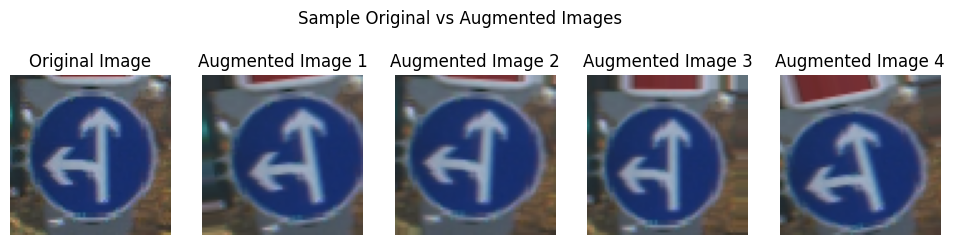

In [ ]:
# Driver Code
show_augmented_images_with_originals(x, aug_datagen_display)

# manually detection the traffic sign and crop the traffic sign

In [ ]:
# detection traffic sign and crop:

In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def detect_and_crop_sign(image):
    """
    Detects a red traffic sign, filters for the best candidate,
    crops it, and resizes to 30,30
    """
    # 1. Convert image to HSV color space
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # 2. Apply mask for red hues (Red wraps around 0 and 180)
    lower_red1 = np.array([0, 70, 50])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([160, 70, 50])
    upper_red2 = np.array([180, 255, 255])

    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask = cv2.add(mask1, mask2)

    # 3. Identify candidate regions using contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    best_candidate = None
    max_area = 0
    min_area_threshold = 500  # Adjust based on expected sign distance

    # 4. Filter contours based on area and aspect ratio
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area_threshold:
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(w) / h

        # Filtering criteria: Aspect ratio close to 1.0 (0.8 to 1.2 range)
        if 0.7 <= aspect_ratio <= 1.3:
            if area > max_area:
                max_area = area
                best_candidate = (x, y, w, h)

    # 5. Extract, Crop, and Resize
    if best_candidate:
        x, y, w, h = best_candidate
        cropped_img = image[y:y+h, x:x+w]

        # Resize to (30, 30) for the Stage 2 classifier
        final_output = cv2.resize(cropped_img, (30, 30), interpolation=cv2.INTER_AREA)
        return final_output

    else:
        # Return a blank (30, 30) image or None if no sign is detected
        return None

# Example usage:
img = cv2.imread("/content/00006.png")
sign = detect_and_crop_sign(img)
if sign is not None:
 cv2_imshow(sign)